   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

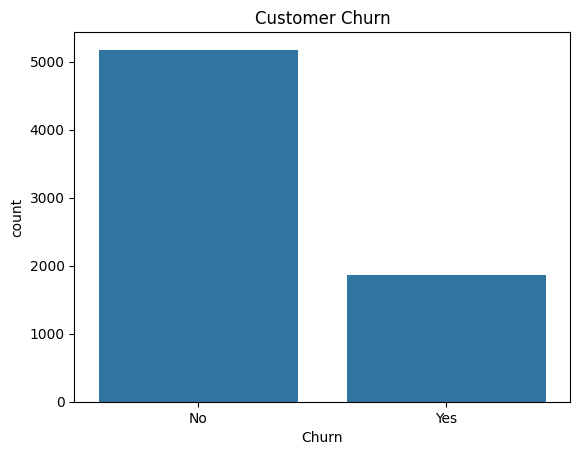

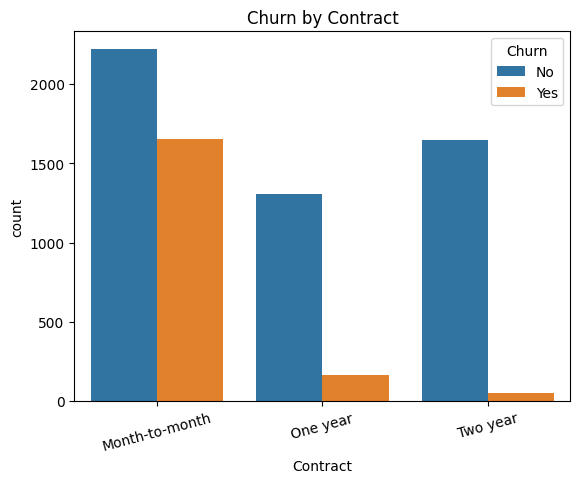

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression ---
Accuracy: 0.8161816891412349
Recall: 0.5764075067024129
ROC-AUC: 0.861509776724254

--- Random Forest ---
Accuracy: 0.7955997161107168
Recall: 0.4718498659517426
ROC-AUC: 0.8369592783131656


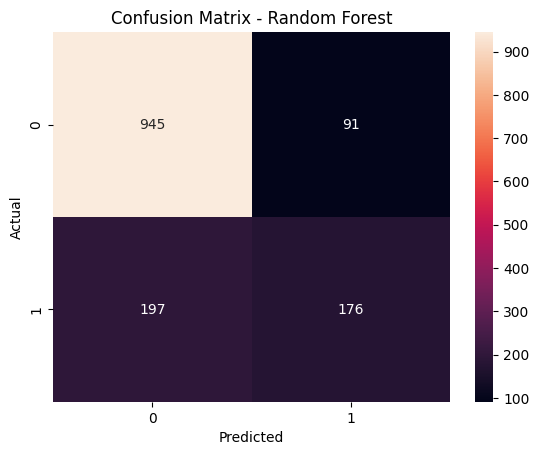


Customer is likely to CHURN


In [2]:
# ==========================================
# CUSTOMER CHURN PREDICTION
# ==========================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix


# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("customer_churn.csv")

print(df.head())
print(df.shape)
print(df.isnull().sum())


# ==========================================
# 2. DATA CLEANING
# ==========================================

# Convert TotalCharges into numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Remove customer ID
df.drop("customerID", axis=1, inplace=True)


# ==========================================
# 3. EDA
# ==========================================

# Churn count
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn")
plt.show()


# Churn by Contract
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn by Contract")
plt.xticks(rotation=15)
plt.show()


# ==========================================
# 4. ENCODE CATEGORICAL DATA
# ==========================================

encoder = LabelEncoder()

for column in df.select_dtypes(
    include="object"
).columns:

    df[column] = encoder.fit_transform(
        df[column]
    )


# ==========================================
# 5. SEPARATE X AND Y
# ==========================================

X = df.drop("Churn", axis=1)

y = df["Churn"]


# ==========================================
# 6. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==========================================
# 7. LOGISTIC REGRESSION
# ==========================================

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:, 1]


print("\n--- Logistic Regression ---")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Recall:",
    recall_score(y_test, lr_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, lr_prob)
)


# ==========================================
# 8. RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:, 1]


print("\n--- Random Forest ---")

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)


# ==========================================
# 9. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ==========================================
# 10. PREDICT A CUSTOMER
# ==========================================

prediction = rf.predict(
    X_test.iloc[[0]]
)

if prediction[0] == 1:
    print("\nCustomer is likely to CHURN")
else:
    print("\nCustomer is likely to STAY")